In [103]:
import pandas as pd
import numpy as np
from pathlib import Path
import os, sys, time
import geopandas as gpd

REPO = Path(os.getcwd()).parent
DATA_ROOT = REPO.parent.parent / 'Data' / 'replication_package'
PLOT_ROOT = DATA_ROOT.parent.parent / 'Plots' / 'Regional'

sys.path.insert(0, os.path.join(REPO, 'Code', 'tools'))
import inequality_analyzers as ia

In [104]:
# Load CBOS data
cbos = pd.read_csv(DATA_ROOT / "CBOS" / "CBOS_survey.csv", low_memory=False)

# Load LIS Voiv
lis_voiv = pd.read_csv(DATA_ROOT / "LIS" / "LIS_Voiv.csv")
# Load LIS Groups
lis_groups = pd.read_csv(DATA_ROOT / "LIS" / "LIS_Groups.csv")

In [105]:
# We create relevant columns
cbos["H_total_income"] = cbos["income_hh_t_imputed"]        # Total household income: income per household member multiplied by household size
cbos["P_income"] = cbos["income_p_imputed"]

# Regional aspect:
# - 1990-1998: old voivodeships (49 units) -> location_old_L
# - 1999-2.2017: new voivodeships (16 units) -> location_new_L
# - 3.2017-12.2017: macroregions (6 units) -> macroregion

# Relevant region columns: location_new_L, location_old_L (and _L their labels), macroregion
# Relevant demographic columns: age, sex_L, household_size, educ_1990_L old education division and educ_2000_L new
# Relevant technical columns: survey_year, survey_month, survey_date, survey_file
# Relevant geolocation columns: G_VOIV_500, G_VOIV_100, G_VOIV_100_500, G_MACRO_500, G_MACRO_100, G_MACRO_100_500

# Original weight column: weight
# Additional weights, their household versions and their normalized versions:
# - weight_VOIV (_h) (_NORM):               weight inside voivodeships (old, new or macroregions whatever is available)
# - weight_VOIV_500 (_h) (_NORM):           weight inside cities 500k+ and rest of voivodeships (old, new or macroregions whatever is available)
# - weight_VOIV_100 (_h) (_NORM):           weight inside cities 100k+ and rest of voivodeships (old, new or macroregions whatever is available)
# - weight_VOIV_100_500 (_h) (_NORM):       weight inside cities 100k+ and 500k+ and rest of voivodeships (old, new or macroregions whatever is available) 
# - weight_MACRO (_h) (_NORM):              weight inside macroregions (available from 1999 onwards)
# - weight_MACRO_500 (_h) (_NORM):          weight inside cities 500k+ and rest of macroregions (available from 1999 onwards)
# - weight_MACRO_100 (_h) (_NORM):          weight inside cities 100k+ and rest of macroregions (available from 1999 onwards)
# - weight_MACRO_100_500 (_h) (_NORM):      weight inside cities 100k+ and 500k+ and rest of macroregions (available from 1999 onwards)

# Deflators (for base year in [1986, 1990, 2017, 2023]):
# - deflator_YYYY: average yearly deflator, with base year in YYYY.
# - deflator_YYYY_m: monthly deflator, with base year in January of YYYY.
relevant_check_columns = ['sex_L', 'age', 'educ_1990_L', 'household_size', 'weight_VOIV_NORM', 'income_hh', 'H_total_income']

In [106]:
# Load plotting package
new_region_gdf = gpd.read_file(DATA_ROOT / 'geometry' / 'geometry.gpkg', layer='new_voivodeships')
region_gdf = gpd.read_file(DATA_ROOT / 'geometry' / 'geometry.gpkg', layer='old_voivodeships')
macroregion_gdf = gpd.read_file(DATA_ROOT / 'geometry' / 'geometry.gpkg', layer='LIS_macroregions')

In [107]:
# Initialize analyzers
# CBOS: microdata analyzer with 2017 PLN deflation
cbos_a = ia.CBOSAnalyzer(cbos, 
                         income_col='H_total_income',
                         weight_col='weight_VOIV_h_NORM',
                         deflator_col='deflator_2023_m'
                         )

# LIS: pre-computed aggregates
lis_voiv_a = ia.LISAnalyzer(lis_voiv, income_type='hitotalnet', deflator_col='deflator_2023')
lis_groups_a = ia.LISAnalyzer(lis_groups, income_type='hitotalnet', deflator_col='deflator_2023')

# Quick summaries
print("CBOS:", cbos_a.summary())
print("LIS Voiv:", lis_voiv_a.summary())
print("LIS Groups:", lis_groups_a.summary())


CBOS: {'n_observations': 355336, 'year_range': (np.int64(1990), np.int64(2017)), 'n_years': 28, 'income_col': 'H_total_income', 'weight_col': 'weight_VOIV_h_NORM', 'deflator_col': 'deflator_2023_m', 'income_non_null': np.int64(352371), 'weight_non_null': np.int64(355336)}
LIS Voiv: {'income_type': 'hitotalnet', 'n_regions': 71, 'year_range': (np.int64(1986), np.int64(2023)), 'n_metrics': 31, 'available_metrics': ['N_total', 'Nw_total', 'mean', 'median', 'p10', 'p25', 'p75', 'p90', 'p99', 'p90p10', 'p90p50', 'p50p10', 'gini', 'theil', 'palma', 'N_Bottom_50', 'Nw_Bottom_50', 'Bottom_50', 'N_P50_90', 'Nw_P50_90', 'P50_90', 'N_Top_10', 'Nw_Top_10', 'Top_10', 'N_Top_1', 'Nw_Top_1', 'Top_1', 'share_Bottom_50', 'share_P50_90', 'share_Top_10', 'share_Top_1'], 'deflator': 'deflator_2023'}
LIS Groups: {'income_type': 'hitotalnet', 'n_regions': 141, 'year_range': (np.int64(1999), np.int64(2023)), 'n_metrics': 31, 'available_metrics': ['N_total', 'Nw_total', 'mean', 'median', 'p10', 'p25', 'p75', 

In [108]:
# Set up for plotting
# Set up for plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Params for clean and minimalistic plots
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (6,6),
    'font.size': 11.0,
    'font.family': 'serif',
    'font.serif': 'Palatino',
    'axes.titlesize': 'medium',
    'figure.titlesize': 'large',
    'legend.fontsize': 'medium',
    # dpi for high-res output
    'figure.dpi': 100,
    'savefig.dpi': 300,
    # Tight layout by default
    'figure.autolayout': True,
    'text.usetex': True,
    'text.latex.preamble': r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{siunitx}[=v2]",
})

COLORS = {
    'CBOS': ["#274690",  # deep sapphire
    "#3B7DD8",  # cornflower-ish
    "#2BB3C0",  # bright teal-cyan
    "#1F9A8A",  # sea-green teal
    "#6B57C9",  # indigo-violet
    "#A78FFF",  # soft lilac
    ],
    'LIS': ["#8B2E2E",  # deep brick
    "#B63E3E",  # warm berry
    "#E06B57",  # terra-cotta / coral
    "#C75B7C",  # dusty rose
    "#9A2442",  # cranberry
    "#5B1F2E",  # maroon
    ]
}

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_32995/3526883460.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lis_regional_1995['region_id'] = lis_regional_1995['region_id'].astype(str).str.zfill(7)
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_32995/3526883460.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lis_regional_1999['region_id'] = lis_regional_1999['region_id'].astype(str).str.zfill(7)
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_32995/3526883460.py

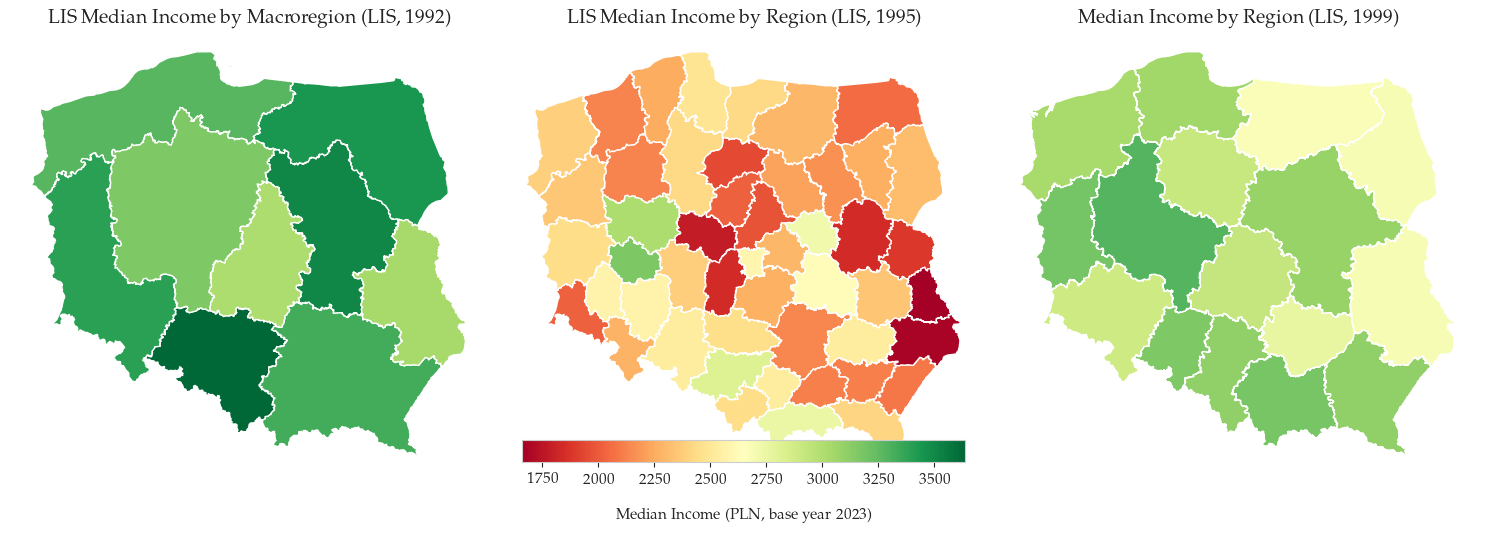

In [109]:

lis_regional = lis_voiv_a.regional_panel(metrics=['share_Bottom_50', 'share_P50_90', 'share_Top_10', 'share_Top_1', 'median'], region_id_col='region_id')

lis_regional_1992 = lis_regional[lis_regional['year'] == 1992]
lis_regional_1995 = lis_regional[lis_regional['year'] == 1995]
lis_regional_1999 = lis_regional[lis_regional['year'] == 1999]

lis_regional_1995['region_id'] = lis_regional_1995['region_id'].astype(str).str.zfill(7)
lis_regional_1999['region_id'] = lis_regional_1999['region_id'].astype(str).str.zfill(7)

# Plot a map of median income by region in 1990
region_gdf['value_1'] = region_gdf['teryt_id'].map(lis_regional_1995.set_index('region_id')['median'])
macroregion_gdf['value_1'] = macroregion_gdf['id'].map(lis_regional_1992.set_index('region_id')['median'])
new_region_gdf['value_1'] = new_region_gdf['teryt_id'].map(lis_regional_1999.set_index('region_id')['median'])

# Three figures side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.subplots_adjust(wspace=-1)
# One colorbar for both maps with cmap RdYlGn
vmin = min(lis_regional_1995['median'].min(), macroregion_gdf['value_1'].min(), new_region_gdf['value_1'].min())
vmax = max(lis_regional_1995['median'].max(), macroregion_gdf['value_1'].max(), new_region_gdf['value_1'].max())

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.RdYlGn
# Create a scalar mappable for the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

# Plot 1992 map
macroregion_gdf.plot(column='value_1', ax=ax1, legend=False, cmap=cmap, norm=norm)
ax1.set_title(f'LIS Median Income by Macroregion (LIS, 1992)', fontsize=14)
ax1.axis('off')

# Plot 1995 map
region_gdf.plot(column='value_1', ax=ax2, legend=False, cmap=cmap, norm=norm)
ax2.set_title(f'LIS Median Income by Region (LIS, 1995)', fontsize=14)
ax2.axis('off')

# Plot 1999 map
new_region_gdf.plot(column='value_1', ax=ax3, legend=False, cmap=cmap, norm=norm)
ax3.set_title(f'Median Income by Region (LIS, 1999)', fontsize=14)
ax3.axis('off')

# Add a single colorbar for both maps
cbar = fig.colorbar(sm, ax=[ax1, ax2, ax3], orientation='horizontal', fraction=0.05, pad=0.01)
cbar.set_label('Median Income (PLN, base year 2023)', rotation=0, labelpad=15)


plt.tight_layout()
plt.savefig(PLOT_ROOT / f'LIS_median_income_map_92_95_95.png', bbox_inches='tight')
plt.show()



/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_32995/1773282165.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lis_regional_2007['region_id'] = lis_regional_2007['region_id'].astype(str).str.zfill(7)
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_32995/1773282165.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lis_regional_2015['region_id'] = lis_regional_2015['region_id'].astype(str).str.zfill(7)
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_32995/1773282165.py

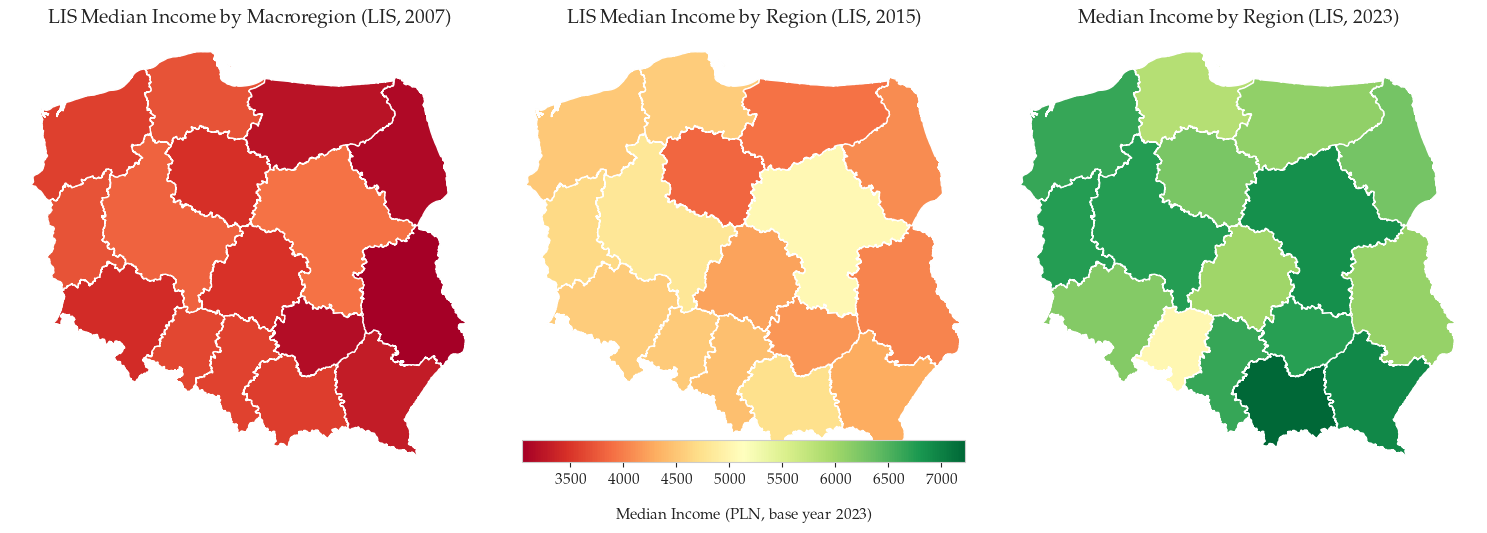

In [110]:

lis_regional = lis_voiv_a.regional_panel(metrics=['share_Bottom_50', 'share_P50_90', 'share_Top_10', 'share_Top_1', 'median'], region_id_col='region_id')

lis_regional_2007 = lis_regional[lis_regional['year'] == 2007]
lis_regional_2015 = lis_regional[lis_regional['year'] == 2015]
lis_regional_2023 = lis_regional[lis_regional['year'] == 2023]

lis_regional_2007['region_id'] = lis_regional_2007['region_id'].astype(str).str.zfill(7)
lis_regional_2015['region_id'] = lis_regional_2015['region_id'].astype(str).str.zfill(7)
lis_regional_2023['region_id'] = lis_regional_2023['region_id'].astype(str).str.zfill(7)

# Plot a map of median income by region in 1990
new_region_gdf['value_1'] = new_region_gdf['teryt_id'].map(lis_regional_2007.set_index('region_id')['median'])
new_region_gdf['value_2'] = new_region_gdf['teryt_id'].map(lis_regional_2015.set_index('region_id')['median'])
new_region_gdf['value_3'] = new_region_gdf['teryt_id'].map(lis_regional_2023.set_index('region_id')['median'])

# Three figures side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.subplots_adjust(wspace=-1)
# One colorbar for both maps with cmap RdYlGn
vmin = min(new_region_gdf['value_1'].min(), new_region_gdf['value_2'].min(), new_region_gdf['value_3'].min())
vmax = max(new_region_gdf['value_1'].max(), new_region_gdf['value_2'].max(), new_region_gdf['value_3'].max())

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.RdYlGn
# Create a scalar mappable for the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

# Plot 1992 map
new_region_gdf.plot(column='value_1', ax=ax1, legend=False, cmap=cmap, norm=norm)
ax1.set_title(f'LIS Median Income by Macroregion (LIS, 2007)', fontsize=14)
ax1.axis('off')

# Plot 1995 map
new_region_gdf.plot(column='value_2', ax=ax2, legend=False, cmap=cmap, norm=norm)
ax2.set_title(f'LIS Median Income by Region (LIS, 2015)', fontsize=14)
ax2.axis('off')

# Plot 1999 map
new_region_gdf.plot(column='value_3', ax=ax3, legend=False, cmap=cmap, norm=norm)
ax3.set_title(f'Median Income by Region (LIS, 2023)', fontsize=14)
ax3.axis('off')

# Add a single colorbar for both maps
cbar = fig.colorbar(sm, ax=[ax1, ax2, ax3], orientation='horizontal', fraction=0.05, pad=0.01)
cbar.set_label('Median Income (PLN, base year 2023)', rotation=0, labelpad=15)


plt.tight_layout()
plt.savefig(PLOT_ROOT / f'LIS_median_income_map_07_15_23.png', bbox_inches='tight')
plt.show()



/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_32995/2664826502.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


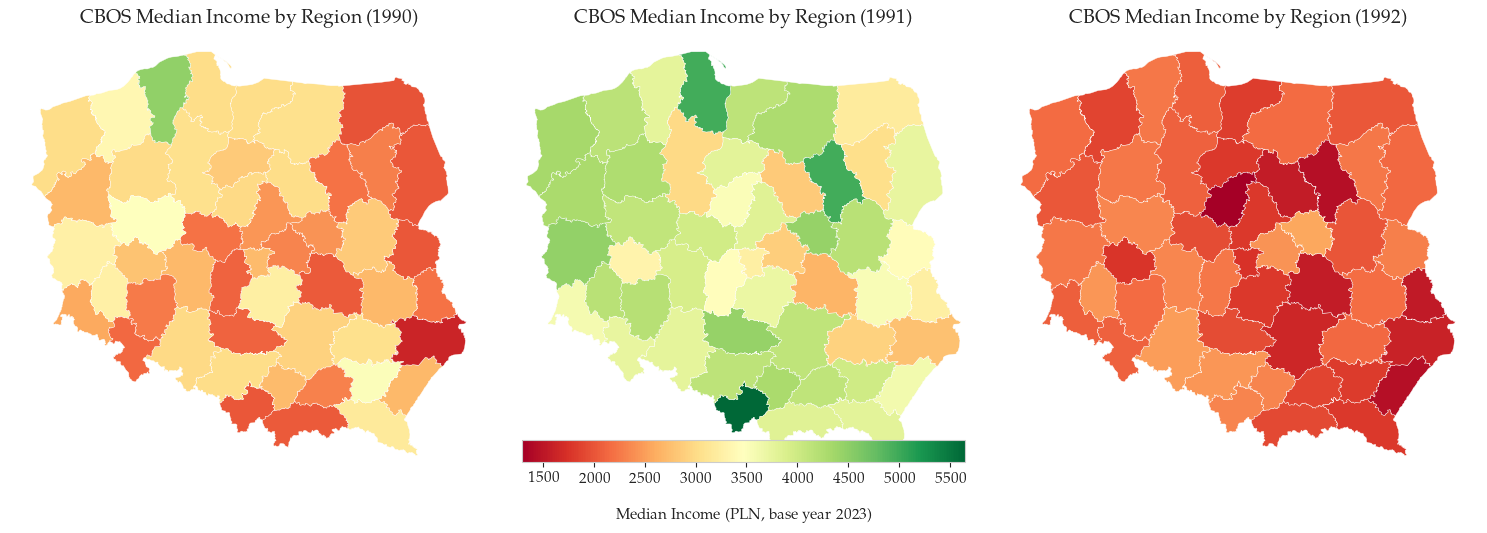

In [113]:

# ── CBOS Median Income panel: 3 snapshots (1993, 2005, 2015) ────────────────
# 1993: old voivodeships (49 units) → region_gdf
# 2005, 2015: new voivodeships (16 units) → new_region_gdf
YEAR_1 = 1990
YEAR_2 = 1991
YEAR_3 = 1992

col_1 = 'location_old_L' if YEAR_1 < 1999 else 'location_new_L'
col_2 = 'location_old_L' if YEAR_2 < 1999 else 'location_new_L'
col_3 = 'location_old_L' if YEAR_3 < 1999 else 'location_new_L'

cbos_1993 = cbos_a.regional_metrics(year=YEAR_1, region_col=col_1,  region_id_col='teryt_id_VOIV')
cbos_2005 = cbos_a.regional_metrics(year=YEAR_2, region_col=col_2,  region_id_col='teryt_id_VOIV')
cbos_2015 = cbos_a.regional_metrics(year=YEAR_3, region_col=col_3,  region_id_col='teryt_id_VOIV')

if YEAR_1 < 1999:
    gdf_1993 = region_gdf.copy()
else:    
    gdf_1993 = new_region_gdf.copy()
    gdf_1993['teryt_id'] = gdf_1993['teryt_id'].astype(str).str.zfill(7)
    cbos_1993['region_id'] = cbos_1993['region_id'].astype(str).str.zfill(7)

if YEAR_2 < 1999:
    gdf_2005 = region_gdf.copy()
else:    
    gdf_2005 = new_region_gdf.copy()
    gdf_2005['teryt_id'] = gdf_2005['teryt_id'].astype(str).str.zfill(7)
    cbos_2005['region_id'] = cbos_2005['region_id'].astype(str).str.zfill(7)
    
if YEAR_3 < 1999:
    gdf_2015 = region_gdf.copy()
else:    
    gdf_2015 = new_region_gdf.copy()
    gdf_2015['teryt_id'] = gdf_2015['teryt_id'].astype(str).str.zfill(7)
    cbos_2015['region_id'] = cbos_2015['region_id'].astype(str).str.zfill(7)


gdf_1993['median'] = gdf_1993['teryt_id'].map(cbos_1993.set_index('region_id')['median'])
gdf_2005['median'] = gdf_2005['teryt_id'].map(cbos_2005.set_index('region_id')['median'])
gdf_2015['median'] = gdf_2015['teryt_id'].map(cbos_2015.set_index('region_id')['median'])

vmin = min(gdf_1993['median'].min(), gdf_2005['median'].min(), gdf_2015['median'].min())
vmax = max(gdf_1993['median'].max(), gdf_2005['median'].max(), gdf_2015['median'].max())

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.RdYlGn
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.subplots_adjust(wspace=-1)

gdf_1993.plot(column='median', ax=ax1, legend=False, cmap=cmap, norm=norm, edgecolor='white', linewidth=0.3)
ax1.set_title(f'CBOS Median Income by Region ({YEAR_1})', fontsize=14)
ax1.axis('off')

gdf_2005.plot(column='median', ax=ax2, legend=False, cmap=cmap, norm=norm, edgecolor='white', linewidth=0.3)
ax2.set_title(f'CBOS Median Income by Region ({YEAR_2})', fontsize=14)
ax2.axis('off')

gdf_2015.plot(column='median', ax=ax3, legend=False, cmap=cmap, norm=norm, edgecolor='white', linewidth=0.3)
ax3.set_title(f'CBOS Median Income by Region ({YEAR_3})', fontsize=14)
ax3.axis('off')

cbar = fig.colorbar(sm, ax=[ax1, ax2, ax3], orientation='horizontal', fraction=0.05, pad=0.01)
cbar.set_label('Median Income (PLN, base year 2023)', rotation=0, labelpad=15)

plt.tight_layout()
plt.savefig(PLOT_ROOT / f'CBOS_median_income_map_{YEAR_1}_{YEAR_2}_{YEAR_3}.png', bbox_inches='tight')
plt.show()


/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_32995/764076227.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


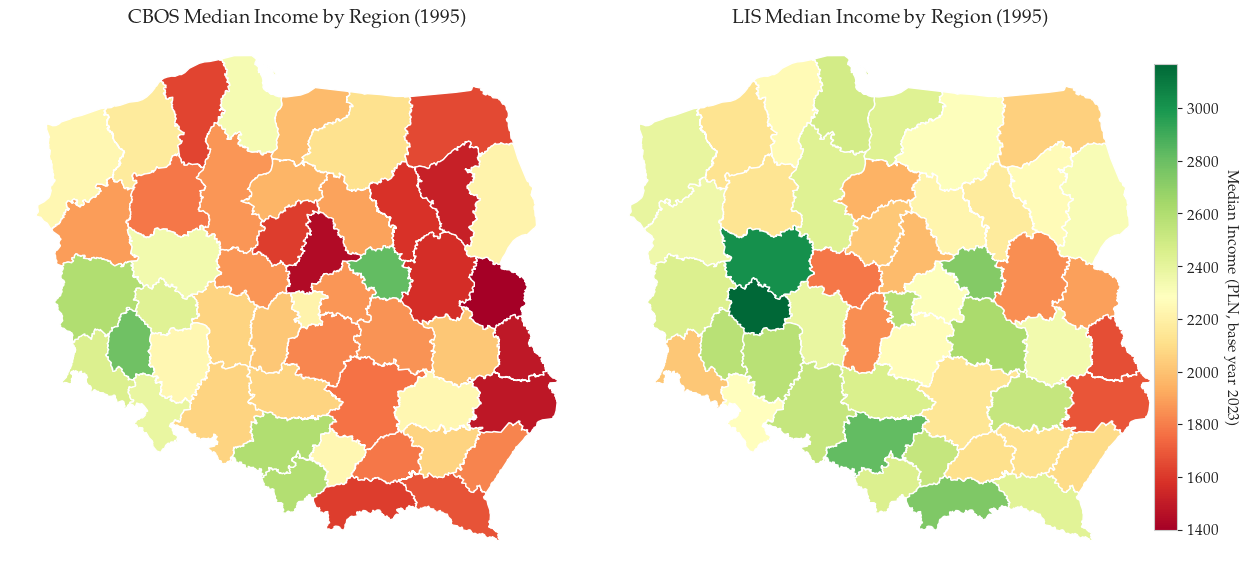

In [68]:
YEAR = 1995

cbos_regional = cbos_a.regional_metrics(year = YEAR, region_col='location_old_L', region_id_col='teryt_id_VOIV')
lis_regional = lis_voiv_a.regional_panel(metrics=['share_Bottom_50', 'share_P50_90', 'share_Top_10', 'share_Top_1', 'median'], region_id_col='region_id')

lis_regional = lis_regional[lis_regional['year'] == YEAR]
lis_regional['region_id'] = lis_regional['region_id'].astype(str)

# Plot a map of median income by region in 1990
region_gdf['value_1'] = region_gdf['teryt_id'].map(cbos_regional.set_index('region_id')['median'])
region_gdf['value_2'] = region_gdf['teryt_id'].map(lis_regional.set_index('region_id')['median'])

# Two figures side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
# Set the same color scale for both maps
vmin = min(region_gdf['value_1'].min(), region_gdf['value_2'].min())
vmax = max(region_gdf['value_1'].max(), region_gdf['value_2'].max())
# One colorbar for both maps with cmap RdYlGn
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.RdYlGn
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# Plot CBOS map
region_gdf.plot(column='value_1', ax=ax1, legend=False, cmap=cmap, norm=norm)
ax1.set_title(f'CBOS Median Income by Region ({YEAR})', fontsize=14)
ax1.axis('off')
# Plot LIS map
region_gdf.plot(column='value_2', ax=ax2, legend=False, cmap=cmap, norm=norm)
ax2.set_title(f'LIS Median Income by Region ({YEAR})', fontsize=14)
ax2.axis('off')
# Add a single colorbar for both maps
cbar = fig.colorbar(sm, ax=[ax1, ax2], orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('Median Income (PLN, base year 2023)', rotation=270, labelpad=15)
plt.tight_layout()
plt.savefig(PLOT_ROOT / f'median_income_map_{YEAR}.png', bbox_inches='tight')
plt.show()




/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_32995/492779710.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


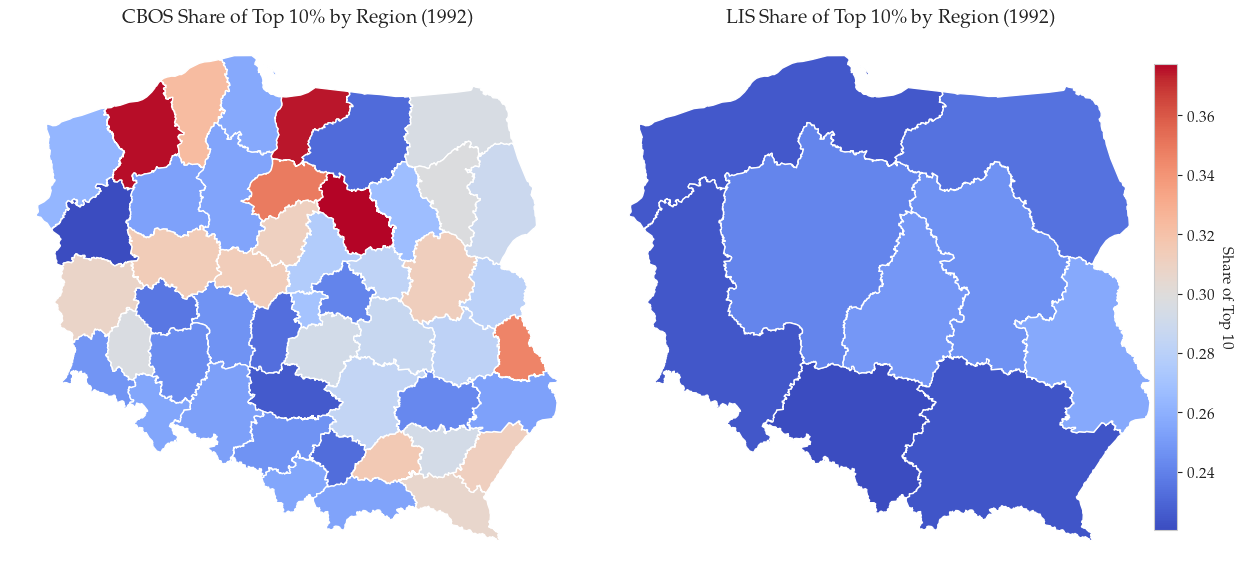

In [69]:
# Shares Top 10%

YEAR = 1992 

cbos_regional = cbos_a.regional_metrics(year = YEAR, region_col='location_old_L', region_id_col='teryt_id_VOIV')
lis_regional = lis_voiv_a.regional_panel(metrics=['share_Bottom_50', 'share_P50_90', 'share_Top_10', 'share_Top_1', 'median'], region_id_col='region_id')

lis_regional = lis_regional[lis_regional['year'] == YEAR]

# Plot a map of median income by region in 1990
region_gdf['value_1'] = region_gdf['teryt_id'].map(cbos_regional.set_index('region_id')['share_Top_10'])
macroregion_gdf['value_1'] = macroregion_gdf['id'].map(lis_regional.set_index('region_id')['share_Top_10'])

# Two figures side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
# One colorbar for both maps with cmap coolwarm
# For cbos windorize the color scale to 1st and 99th percentiles to avoid outliers dominating the color scheme
vmin_cbos = cbos_regional['share_Top_10'].quantile(0.02)
vmax_cbos = cbos_regional['share_Top_10'].quantile(0.98)

vmin_lis = macroregion_gdf['value_1'].min()
vmax_lis = macroregion_gdf['value_1'].max()

norm = mpl.colors.Normalize(vmin=min(vmin_cbos, vmin_lis), vmax=max(vmax_cbos, vmax_lis))
cmap = plt.cm.coolwarm
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# Plot CBOS map
region_gdf.plot(column='value_1', ax=ax1, legend=False, cmap=cmap, norm=norm)
ax1.set_title(f'CBOS Share of Top 10\% by Region ({YEAR})', fontsize=14)
ax1.axis('off')
# Plot LIS map
macroregion_gdf.plot(column='value_1', ax=ax2, legend=False, cmap=cmap, norm=norm)
ax2.set_title(f'LIS Share of Top 10\% by Region ({YEAR})', fontsize=14)
ax2.axis('off')
# Add a single colorbar for both maps
cbar = fig.colorbar(sm, ax=[ax1, ax2], orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('Share of Top 10%', rotation=270, labelpad=15)
plt.tight_layout()
plt.savefig(PLOT_ROOT / f'share_top_10_map_{YEAR}.png', bbox_inches='tight')
plt.show()

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_32995/291530791.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


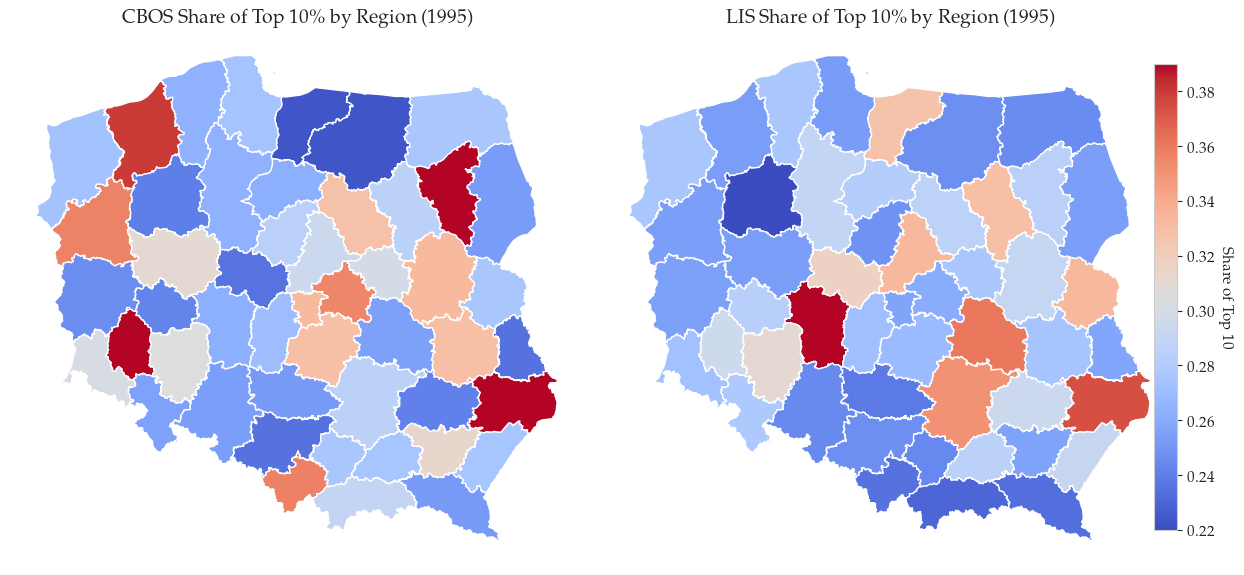

In [70]:
# Shares Top 10%

YEAR = 1995

cbos_regional = cbos_a.regional_metrics(year = YEAR, region_col='location_old_L', region_id_col='teryt_id_VOIV')
lis_regional = lis_voiv_a.regional_panel(metrics=['share_Bottom_50', 'share_P50_90', 'share_Top_10', 'share_Top_1', 'median'], region_id_col='region_id')

lis_regional = lis_regional[lis_regional['year'] == YEAR]
lis_regional['region_id'] = lis_regional['region_id'].astype(str)

# Plot a map of median income by region in 1990
region_gdf['value_1'] = region_gdf['teryt_id'].map(cbos_regional.set_index('region_id')['share_Top_10'])
region_gdf['value_2'] = region_gdf['teryt_id'].map(lis_regional.set_index('region_id')['share_Top_10'])

# Two figures side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
# One colorbar for both maps with cmap coolwarm

v_min_cbos = cbos_regional['share_Top_10'].min()
v_max_cbos = cbos_regional['share_Top_10'].max()

vmin_lis = region_gdf['value_2'].min()
vmax_lis = region_gdf['value_2'].max()

norm = mpl.colors.Normalize(vmin=min(vmin_cbos, vmin_lis), vmax=max(vmax_cbos, vmax_lis))
cmap = plt.cm.coolwarm
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# Plot CBOS map
region_gdf.plot(column='value_1', ax=ax1, legend=False, cmap=cmap, norm=norm)
ax1.set_title(f'CBOS Share of Top 10\% by Region ({YEAR})', fontsize=14)
ax1.axis('off')
# Plot LIS map
region_gdf.plot(column='value_2', ax=ax2, legend=False, cmap=cmap, norm=norm)
ax2.set_title(f'LIS Share of Top 10\% by Region ({YEAR})', fontsize=14)
ax2.axis('off')
# Add a single colorbar for both maps
cbar = fig.colorbar(sm, ax=[ax1, ax2], orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('Share of Top 10%', rotation=270, labelpad=15)
plt.tight_layout()
plt.savefig(PLOT_ROOT / f'share_top_10_map_{YEAR}.png', bbox_inches='tight')
plt.show()

In [71]:
# ── Cell 7: Theil between/within decomposition (old voivodeships, 1990-1998) ─
theil_ts = cbos_a.regional_theil_timeseries('location_old_L', year_range=(1990, 1998))
display(theil_ts[['year', 'total_theil', 'between', 'within', 'between_pct', 'within_pct']].round(4))

,year,total_theil,between,within,between_pct,within_pct
0,1990,0.4034,0.0140,0.3894,3.4630,96.5370
1,1991,0.3074,0.0077,0.2997,2.5073,97.4927
2,1992,0.2395,0.0099,0.2296,4.1279,95.8721
3,1993,0.2719,0.0176,0.2544,6.4604,93.5396
4,1994,0.2531,0.0162,0.2369,6.3908,93.6092
5,1995,0.2452,0.0141,0.2311,5.7582,94.2418
6,1996,0.2406,0.0139,0.2268,5.7562,94.2438
7,1997,0.2695,0.0120,0.2575,4.4571,95.5429
8,1998,0.2833,0.0189,0.2644,6.6757,93.3243


In [72]:
# ── Theil group contributions: which voivodeships drive total inequality? ─────
# Reload module to pick up the new methods
import importlib; importlib.reload(ia)

# Re-initialize analyzers after reload
cbos_a = ia.CBOSAnalyzer(cbos, income_col='H_total_income',
                         weight_col='weight_VOIV_h_NORM',
                         deflator_col='deflator_2023_m')
lis_voiv_a = ia.LISAnalyzer(lis_voiv, income_type='hitotalnet', deflator_col='deflator_2023')

# CBOS: per-voivodeship contributions for 1995 (with region_id for map merging)
cbos_contrib_1995 = cbos_a.theil_contributions(1995, 'location_old_L',
                                                region_id_col='teryt_id_VOIV')
print("=== CBOS: Voivodeship contributions to total Theil T (1995) ===")
display(cbos_contrib_1995.sort_values('total_contribution', ascending=False)
        [['group', 'region_id', 'income_share', 'between_contribution', 'within_contribution',
          'total_contribution', 'contribution_pct']].round(4))

# CBOS: contribution timeseries (1990-1998, with region_id)
cbos_contrib_ts = cbos_a.theil_contribution_timeseries('location_old_L',
                                                        year_range=(1990, 1998),
                                                        region_id_col='teryt_id_VOIV')
print(f"\nPanel shape: {cbos_contrib_ts.shape}  |  Groups: {cbos_contrib_ts['group'].nunique()}  |  Years: {sorted(cbos_contrib_ts['year'].unique())}")


=== CBOS: Voivodeship contributions to total Theil T (1995) ===


,group,region_id,income_share,between_contribution,within_contribution,total_contribution,contribution_pct
41,warszawskie,5800000,0.0998,0.0279,0.0272,0.0551,22.4762
12,katowickie,8700000,0.1138,0.0069,0.0192,0.0261,10.6242
27,poznańskie,7200000,0.0412,0.0086,0.0111,0.0197,8.0392
2,bielskie,9700000,0.0285,0.0073,0.0112,0.0185,7.5583
48,łódzkie,5100000,0.0393,0.0044,0.0134,0.0177,7.2293
18,legnickie,8100000,0.0180,0.0061,0.0052,0.0113,4.6003
43,wrocławskie,5600000,0.0338,0.0036,0.0075,0.0111,4.5289
16,krakowskie,8300000,0.0340,0.0024,0.0076,0.0100,4.0595
36,szczecińskie,6300000,0.0301,0.0032,0.0064,0.0096,3.9101
8,gdańskie,9100000,0.0392,0.0014,0.0079,0.0093,3.7931



Panel shape: (441, 11)  |  Groups: 49  |  Years: [np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998)]


In [73]:
# ── LIS: per-voivodeship Theil contributions ─────────────────────────────────
lis_contrib_1995 = lis_voiv_a.theil_contributions(1995, region_id_col='region_id')
print("=== LIS: Voivodeship contributions to total Theil T (1995) ===")
display(lis_contrib_1995.sort_values('total_contribution', ascending=False)
        [['group', 'region_id', 'income_share', 'between_contribution', 'within_contribution',
          'total_contribution', 'contribution_pct']].round(4))

# LIS: contribution timeseries (all available years, with region_id)
lis_contrib_ts = lis_voiv_a.theil_contribution_timeseries(region_id_col='region_id')
print(f"\nPanel shape: {lis_contrib_ts.shape}  |  Groups: {lis_contrib_ts['group'].nunique()}  |  Years: {sorted(lis_contrib_ts['year'].unique())}")


=== LIS: Voivodeship contributions to total Theil T (1995) ===


,group,region_id,income_share,between_contribution,within_contribution,total_contribution,contribution_pct
12,Katowickie,8700000,0.1198,0.0134,0.0219,0.0353,14.9730
44,Warszawskie,5800000,0.0856,0.0114,0.0196,0.0311,13.1714
11,Kaliskie,8800000,0.0213,0.0048,0.0109,0.0156,6.6339
46,Wroclawskie,5600000,0.0340,0.0039,0.0107,0.0146,6.1934
32,Radomskie,6900000,0.0230,0.0033,0.0105,0.0138,5.8391
30,Poznanskie,7200000,0.0389,0.0051,0.0075,0.0126,5.3295
13,Kieleckie,8600000,0.0291,-0.0014,0.0109,0.0095,4.0500
8,Gdanskie,9100000,0.0393,0.0016,0.0072,0.0088,3.7262
3,Bydgoskie,9600000,0.0287,0.0012,0.0071,0.0083,3.5285
20,Lodzkie,5100000,0.0358,0.0010,0.0069,0.0079,3.3419



Panel shape: (403, 11)  |  Groups: 71  |  Years: [np.int64(1986), np.int64(1992), np.int64(1995), np.int64(1999), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


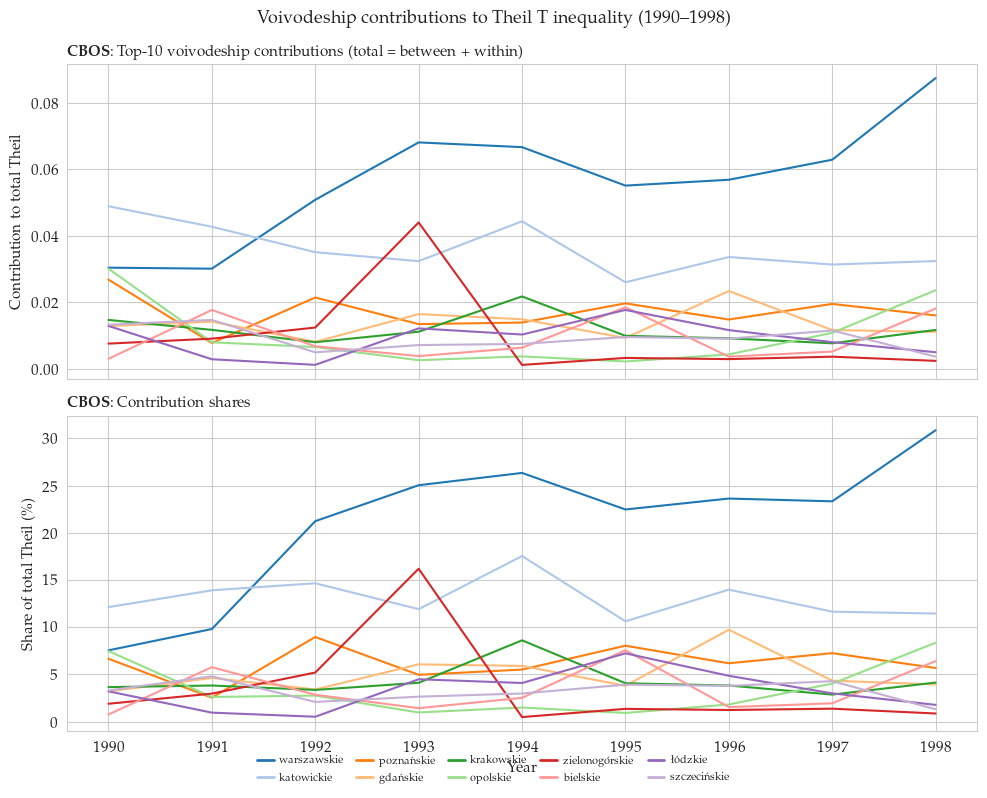

In [74]:
from matplotlib.lines import Line2D

# ── Plot: Top-10 voivodeships by average contribution (CBOS, 1990-1998) ──────
avg_contrib = (cbos_contrib_ts.groupby('group')['total_contribution']
               .mean().sort_values(ascending=False))
top10 = avg_contrib.head(10).index.tolist()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.subplots_adjust(hspace=0.08, bottom=0.18)
cmap = plt.cm.tab20
colors = [cmap(i) for i in range(10)]

# --- Top panel: stacked between vs within contribution for top-10 ---
for i, grp in enumerate(top10):
    d = cbos_contrib_ts[cbos_contrib_ts['group'] == grp].sort_values('year')
    ax1.plot(d['year'], d['total_contribution'], color=colors[i], lw=1.5)
ax1.set_ylabel('Contribution to total Theil')
ax1.set_title(r'\textbf{CBOS}: Top-10 voivodeship contributions (total = between + within)', fontsize=11, loc='left')

# --- Bottom panel: contribution_pct over time ---
for i, grp in enumerate(top10):
    d = cbos_contrib_ts[cbos_contrib_ts['group'] == grp].sort_values('year')
    ax2.plot(d['year'], d['contribution_pct'], color=colors[i], lw=1.5)
ax2.set_ylabel(r'Share of total Theil (\%)')
ax2.set_xlabel('Year')
ax2.set_title(r'\textbf{CBOS}: Contribution shares', fontsize=11, loc='left')

# Short labels for legend
short_labels = [g[:20] for g in top10]
_h = [Line2D([0],[0], color=colors[i], lw=2) for i in range(10)]
fig.legend(_h, short_labels, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, 0.0), frameon=False,
           handlelength=1.5, handletextpad=0.5, columnspacing=1.2, fontsize=8)
fig.suptitle('Voivodeship contributions to Theil T inequality (1990--1998)', fontsize=13)
#plt.savefig(PLOT_ROOT / "theil_contributions_top10_voiv_1990_1998.png", bbox_inches='tight')
plt.show()


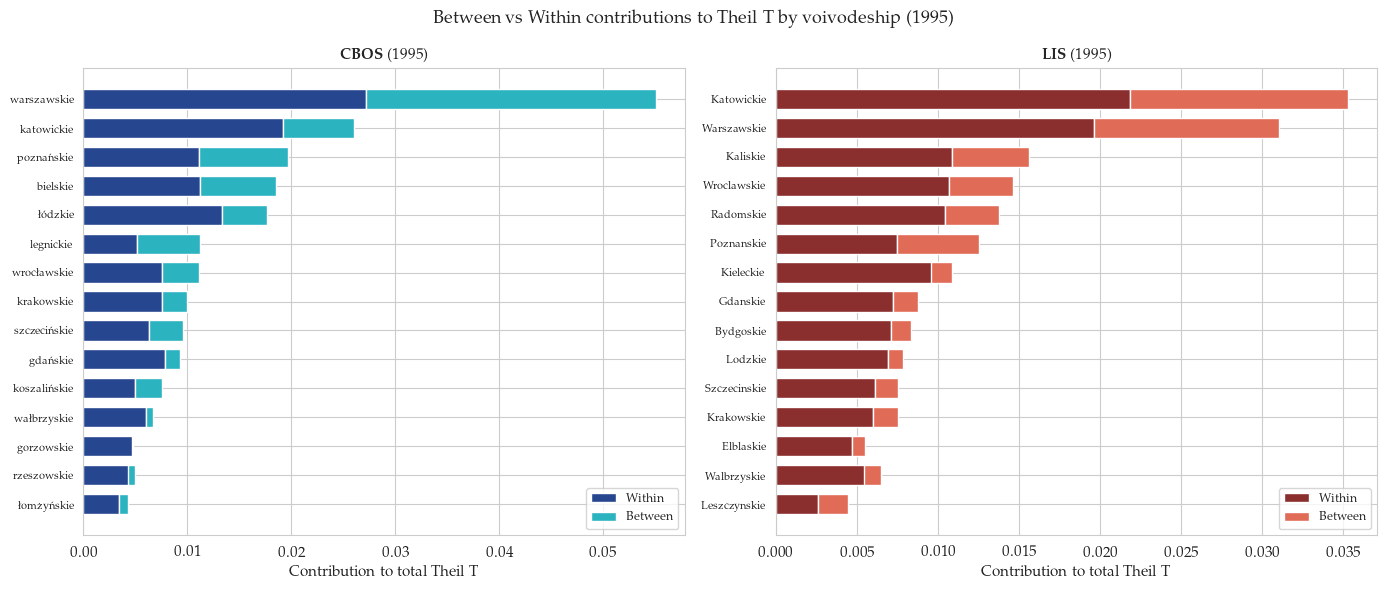

In [75]:
# ── Stacked bar: Between vs Within contribution by voivodeship (1995) ────────
# Top 15 by total contribution
cbos_1995 = cbos_contrib_1995.sort_values('total_contribution', ascending=True).tail(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.subplots_adjust(wspace=0.45)

# CBOS
ax1.barh(range(len(cbos_1995)), cbos_1995['within_contribution'].values,
         color=COLORS['CBOS'][0], label='Within', height=0.7)
ax1.barh(range(len(cbos_1995)), cbos_1995['between_contribution'].values,
         left=cbos_1995['within_contribution'].values,
         color=COLORS['CBOS'][2], label='Between', height=0.7)
ax1.set_yticks(range(len(cbos_1995)))
ax1.set_yticklabels(cbos_1995['group'].values, fontsize=8)
ax1.set_xlabel('Contribution to total Theil T')
ax1.set_title(r'\textbf{CBOS} (1995)', fontsize=11)
ax1.legend(fontsize=9)

# LIS (same year)
if not lis_contrib_1995.empty:
    lis_1995 = lis_contrib_1995.sort_values('total_contribution', ascending=True).tail(15)
    ax2.barh(range(len(lis_1995)), lis_1995['within_contribution'].values,
             color=COLORS['LIS'][0], label='Within', height=0.7)
    ax2.barh(range(len(lis_1995)), lis_1995['between_contribution'].values,
             left=lis_1995['within_contribution'].values,
             color=COLORS['LIS'][2], label='Between', height=0.7)
    ax2.set_yticks(range(len(lis_1995)))
    ax2.set_yticklabels(lis_1995['group'].values, fontsize=8)
    ax2.set_xlabel('Contribution to total Theil T')
    ax2.set_title(r'\textbf{LIS} (1995)', fontsize=11)
    ax2.legend(fontsize=9)

fig.suptitle('Between vs Within contributions to Theil T by voivodeship (1995)', fontsize=13)
plt.savefig(PLOT_ROOT / "theil_between_within_bar_voiv_1995.png", bbox_inches='tight')
plt.show()


/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_32995/2519762975.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_map = plt.cm.get_cmap(cmap_name)
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_32995/2519762975.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_map = plt.cm.get_cmap(cmap_name)
/Users/jedrek/miniforge3/envs/py313/lib/python3.13/site-packages/geopandas/plotting.py:950: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ax.figure.canvas.draw_idle()
/Users/jedrek/miniforge3/envs/py313/lib/python3.13/site-packages/geopandas

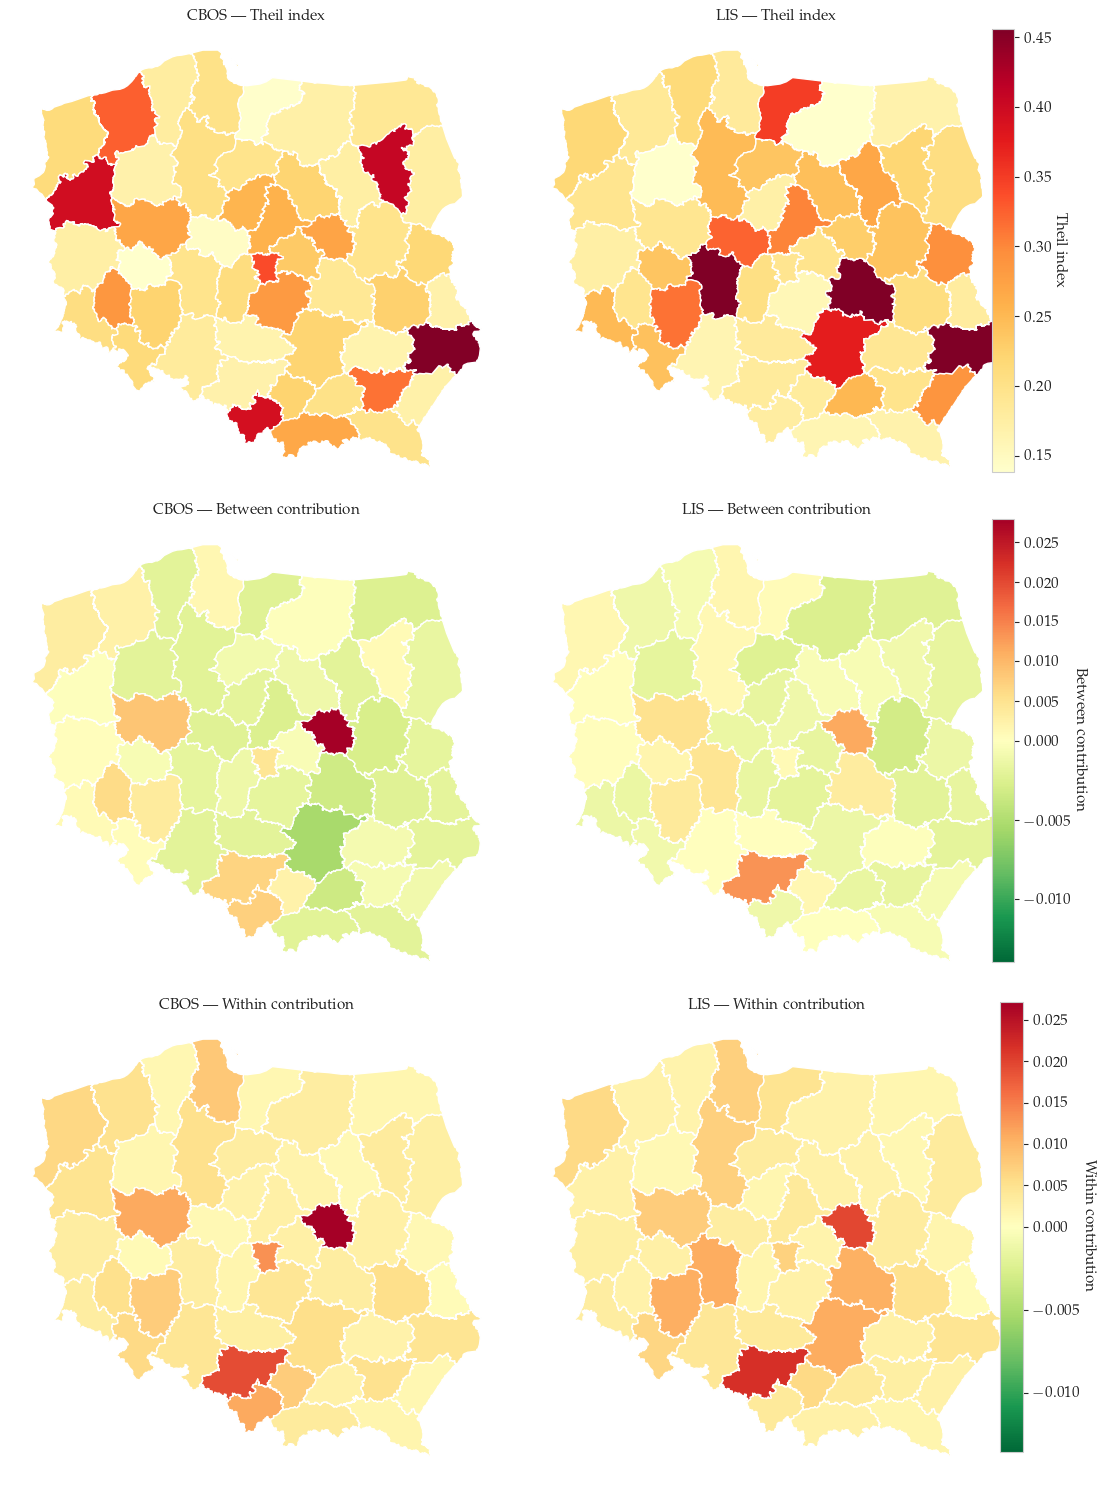

In [76]:
# ── Map: Theil index & contributions — CBOS vs LIS side by side (1995) ───────
YEAR = 1995

# CBOS: regional metrics for Theil index per voivodeship
cbos_reg = cbos_a.regional_metrics(YEAR, region_col='location_old_L', region_id_col='teryt_id_VOIV')
# CBOS contributions (region_id already populated via region_id_col)
cbos_ctr = cbos_a.theil_contributions(YEAR, 'location_old_L', region_id_col='teryt_id_VOIV')

# LIS: regional panel for Theil index per voivodeship
lis_reg = lis_voiv_a.regional_panel(metrics=['theil'], region_id_col='region_id')
lis_reg = lis_reg[lis_reg['year'] == YEAR].copy()
lis_reg['region_id'] = lis_reg['region_id'].astype(str)
# LIS contributions
lis_ctr = lis_voiv_a.theil_contributions(YEAR, region_id_col='region_id')
lis_ctr['region_id'] = lis_ctr['region_id'].astype(str)

# Row definitions: (cbos_data, cbos_col, lis_data, lis_col, label, cmap, diverging)
panel_rows = [
    (cbos_reg, 'theil',                lis_reg, 'theil',                'Theil index',            'YlOrRd',    False),
    (cbos_ctr, 'between_contribution', lis_ctr, 'between_contribution', 'Between contribution',   'RdYlGn_r',  True),
    (cbos_ctr, 'within_contribution',  lis_ctr, 'within_contribution',  'Within contribution',    'RdYlGn_r',  True),
]

fig, axes = plt.subplots(len(panel_rows), 2, figsize=(12, 5 * len(panel_rows)))
fig.subplots_adjust(hspace=0.25, wspace=0.05)

for row, (c_data, c_col, l_data, l_col, label, cmap_name, diverging) in enumerate(panel_rows):
    # Build value maps
    c_id_col = 'region_id'
    c_vals = c_data.set_index(c_id_col)[c_col]
    l_vals = l_data.set_index('region_id')[l_col]
    all_vals = pd.concat([c_vals, l_vals]).dropna()

    if diverging:
        vabs = max(abs(all_vals.min()), abs(all_vals.max()))
        norm = mpl.colors.TwoSlopeNorm(vmin=-vabs * 0.5, vcenter=0, vmax=vabs)
    else:
        norm = mpl.colors.Normalize(vmin=np.percentile(all_vals.values,2), vmax=np.percentile(all_vals.values,98))
    cmap_map = plt.cm.get_cmap(cmap_name)

    # CBOS (left)
    gdf_c = region_gdf.copy()
    gdf_c['value'] = gdf_c['teryt_id'].map(c_vals)
    gdf_c.plot(column='value', ax=axes[row, 0], legend=False, cmap=cmap_map, norm=norm)
    axes[row, 0].set_title(f'CBOS — {label}', fontsize=11)
    axes[row, 0].axis('off')

    # LIS (right)
    gdf_l = region_gdf.copy()
    gdf_l['value'] = gdf_l['teryt_id'].map(l_vals)
    gdf_l.plot(column='value', ax=axes[row, 1], legend=False, cmap=cmap_map, norm=norm)
    axes[row, 1].set_title(f'LIS — {label}', fontsize=11)
    axes[row, 1].axis('off')

    # shared colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap_map, norm=norm)
    cbar = fig.colorbar(sm, ax=axes[row, :].tolist(), orientation='vertical', fraction=0.02, pad=0.01)
    cbar.set_label(label, rotation=270, labelpad=12)

#fig.suptitle(f'Theil index and contributions by voivodeship — CBOS vs LIS ({YEAR})', fontsize=14)
plt.savefig(PLOT_ROOT / f"theil_contributions_map_cbos_vs_lis_{YEAR}.png", bbox_inches='tight')
plt.show()


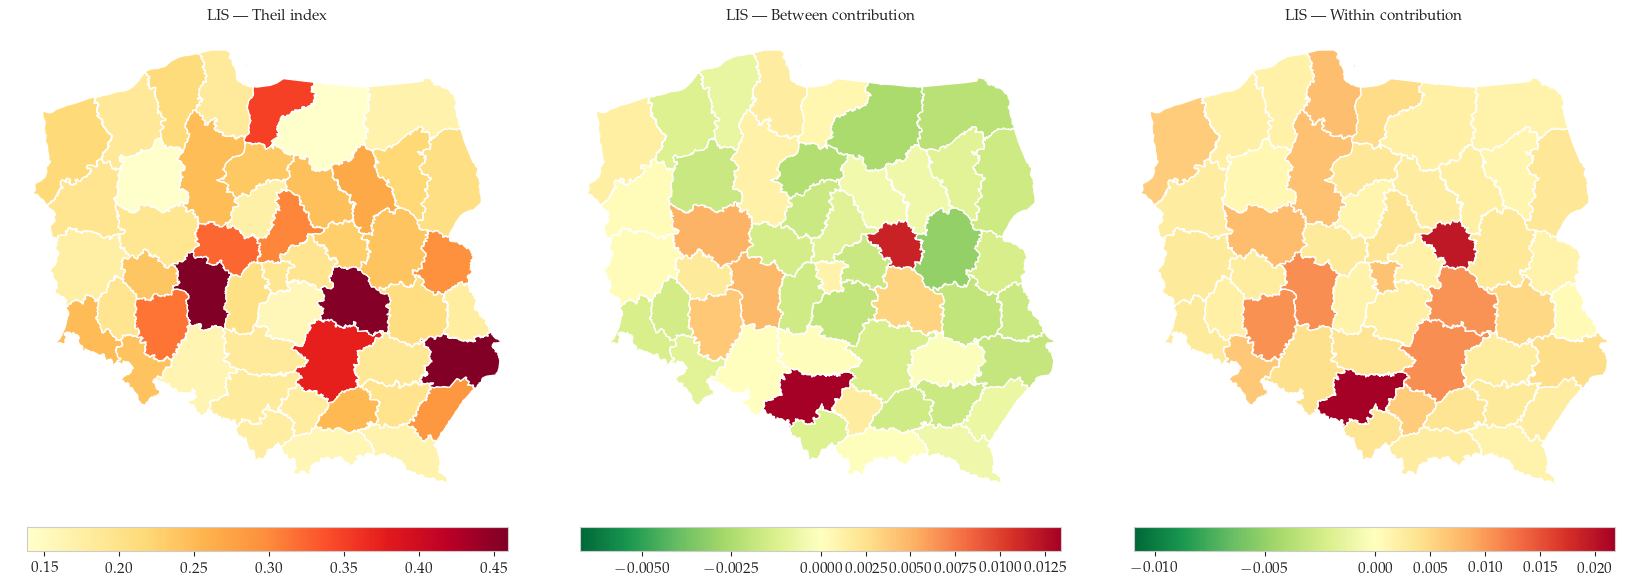

In [77]:
# ── Map: Theil index & contributions — LIS only (1995) ───────────────────────
YEAR = 1995

# LIS: regional panel for Theil index per voivodeship
lis_reg = lis_voiv_a.regional_panel(metrics=['theil'], region_id_col='region_id')
lis_reg = lis_reg[lis_reg['year'] == YEAR].copy()
lis_reg['region_id'] = lis_reg['region_id'].astype(str)
# LIS contributions
lis_ctr = lis_voiv_a.theil_contributions(YEAR, region_id_col='region_id')
lis_ctr['region_id'] = lis_ctr['region_id'].astype(str)

# Plot definitions: (data, col, label, cmap, diverging)
plot_defs = [
    (lis_reg, 'theil',                'Theil index',          'YlOrRd',   False),
    (lis_ctr, 'between_contribution', 'Between contribution', 'RdYlGn_r', True),
    (lis_ctr, 'within_contribution',  'Within contribution',  'RdYlGn_r', True),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.subplots_adjust(wspace=0.05)

for col, (data, val_col, label, cmap_name, diverging) in enumerate(plot_defs):
    vals = data.set_index('region_id')[val_col]

    if diverging:
        vabs = max(abs(vals.min()), abs(vals.max()))
        norm = mpl.colors.TwoSlopeNorm(vmin=-vabs * 0.5, vcenter=0, vmax=vabs)
    else:
        norm = mpl.colors.Normalize(vmin=np.percentile(vals.dropna().values, 2),
                                    vmax=np.percentile(vals.dropna().values, 98))
    cmap_map = mpl.colormaps[cmap_name]

    gdf = region_gdf.copy()
    gdf['value'] = gdf['teryt_id'].map(vals)
    gdf.plot(column='value', ax=axes[col], legend=False, cmap=cmap_map, norm=norm)
    axes[col].set_title(f'LIS — {label}', fontsize=11)
    axes[col].axis('off')

    sm = plt.cm.ScalarMappable(cmap=cmap_map, norm=norm)
    fig.colorbar(sm, ax=axes[col], orientation='horizontal', fraction=0.046, pad=0.04)

plt.savefig(PLOT_ROOT / f"theil_contributions_map_lis_{YEAR}.png", bbox_inches='tight')
plt.show()

**Theil decomposition by voivodeship — interpretation.**

The Theil T index is *exactly* decomposable: each voivodeship's contribution to national inequality has two additive parts:

$$T = \sum_g \underbrace{s_g \ln\!\left(\frac{\mu_g}{\mu}\right)}_{\text{between}_g} + \sum_g \underbrace{s_g \, T_g}_{\text{within}_g}$$

where $s_g = \frac{\sum_{i \in g} w_i y_i}{\sum_i w_i y_i}$ is the *income share* (not population share) of voivodeship $g$.

Key findings (1990–1998):

- **Warsaw (m.st. Warszawa)** consistently contributes the most to total inequality — both because it has high *within-group* dispersion (a wide internal income distribution) and a large positive *between-group* term (its mean income exceeds the national average, so $\ln(\mu_g/\mu) > 0$).
- Other large urban voivodeships (Katowice, Kraków, Gdańsk, Łódź, Wrocław, Poznań) also have substantial contributions, mainly from the within component.
- Poorer, rural voivodeships can show *negative* between-group contributions ($\mu_g < \mu$, so $\ln(\mu_g/\mu) < 0$) — their below-average income *reduces* measured between-group inequality.
- Both CBOS and LIS paint a broadly consistent picture: the ranking of voivodeships by Theil contribution is similar despite different data sources.
- Over time, Warsaw's contribution share grew, consistent with the concentration of transition-era economic gains in the capital.
